C:\Users\Ayush\AppData\Local\Temp\ipykernel_5896\3291597557.py:36: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  cars_data['name'] = cars_data['name'].replace(brand_mapping)
C:\Users\Ayush\AppData\Local\Temp\ipykernel_5896\3291597557.py:38: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  cars_data['transmission'] = cars_data['transmission'].replace({'Manual': 1, 'Automatic': 2})
C:\Users\Ayush\AppData\Local\Temp\ipykernel_5896\3291597557.py:39: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a f

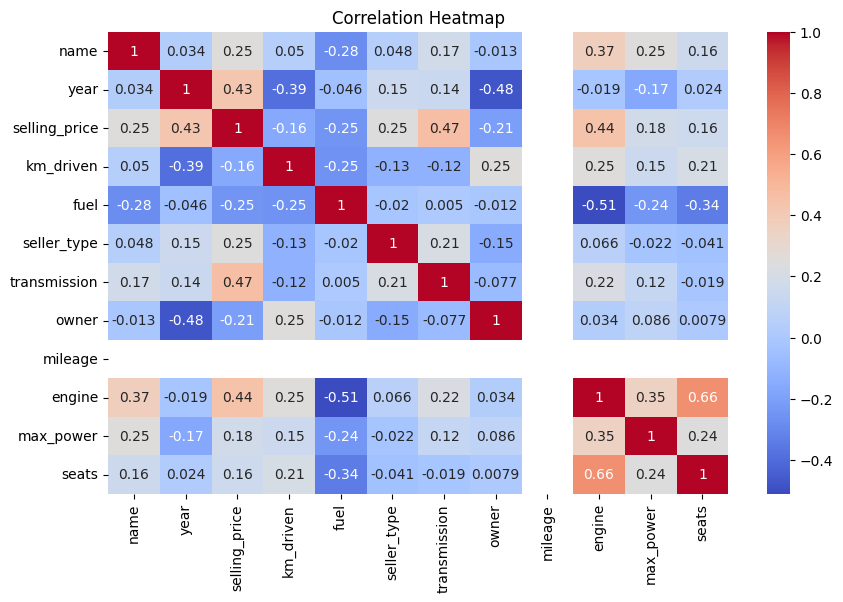

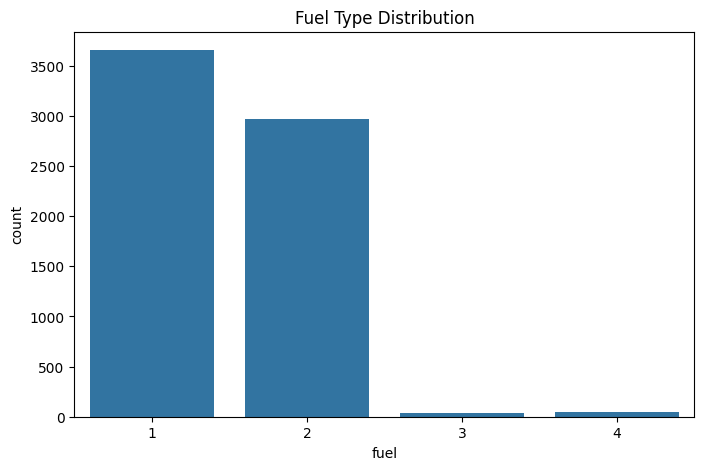

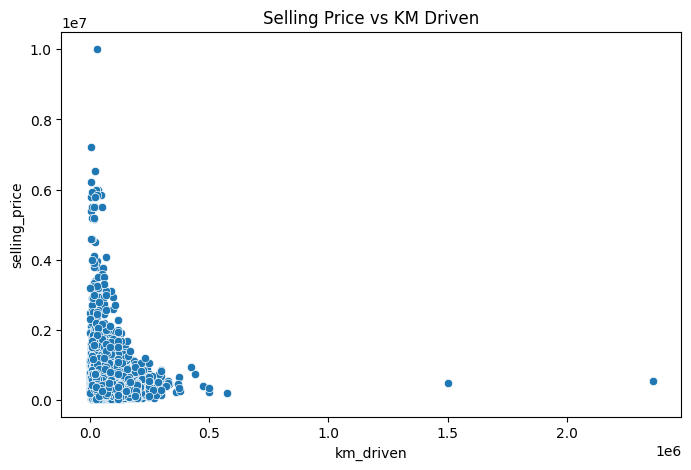

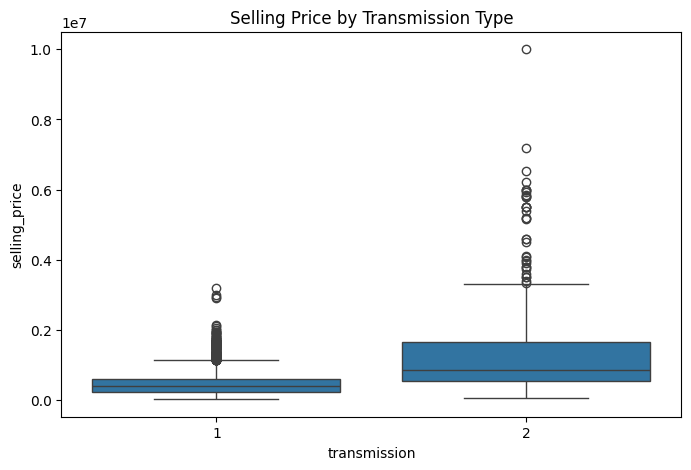

C:\Users\Ayush\AppData\Local\Temp\ipykernel_5896\3291597557.py:65: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(x='owner', y='selling_price', data=cars_data, ci=None)


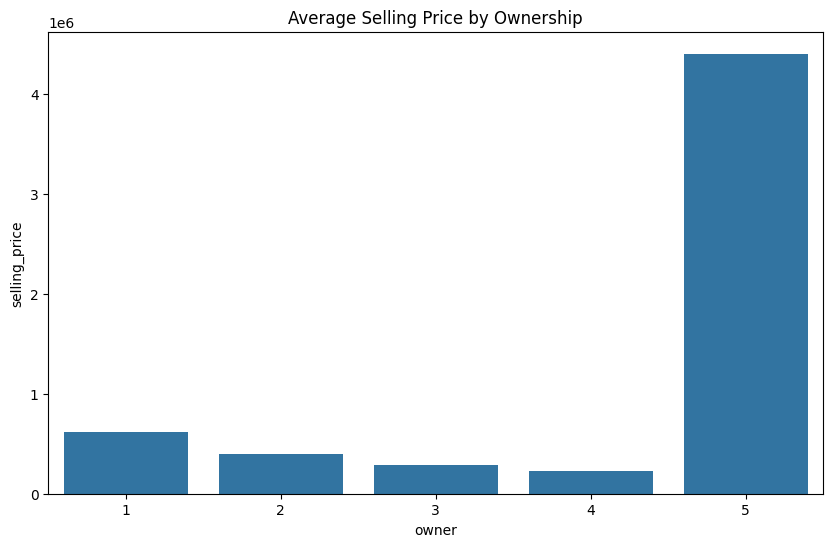

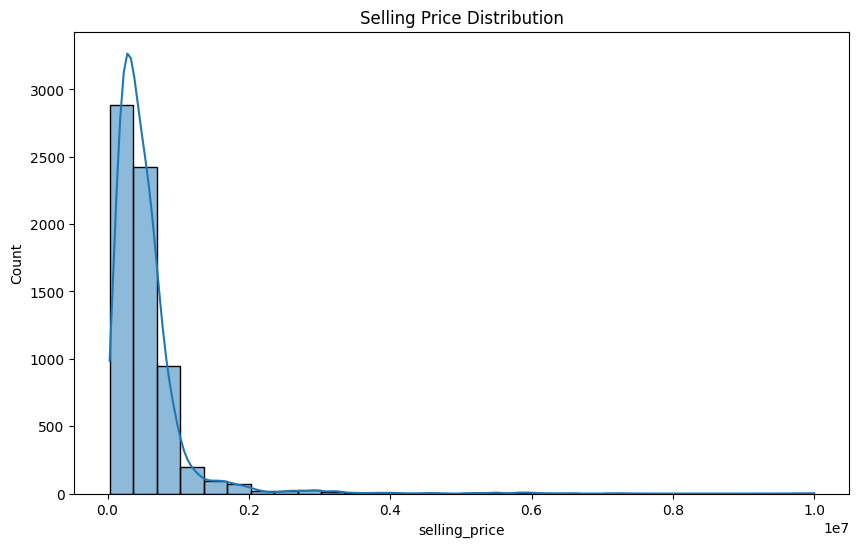

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import pickle as pk

# Load the data
cars_data = pd.read_csv('Cardetails.csv')

# Preprocessing
cars_data = cars_data.drop(columns=['torque'])
cars_data = cars_data.drop_duplicates()

# Handle missing values
cars_data = cars_data.dropna()

# Helper functions
def get_brand_name(car_name):
    return car_name.split(' ')[0].strip()

def clean_data(value):
    value = value.split(' ')[0].strip()
    return float(value) if value.isdigit() else 0

# Clean and encode data
cars_data['name'] = cars_data['name'].apply(get_brand_name)
cars_data['mileage'] = cars_data['mileage'].apply(clean_data)
cars_data['max_power'] = cars_data['max_power'].apply(clean_data)
cars_data['engine'] = cars_data['engine'].apply(clean_data)

# Encode categorical columns
brand_mapping = {brand: idx + 1 for idx, brand in enumerate(cars_data['name'].unique())}
cars_data['name'] = cars_data['name'].replace(brand_mapping)

cars_data['transmission'] = cars_data['transmission'].replace({'Manual': 1, 'Automatic': 2})
cars_data['seller_type'] = cars_data['seller_type'].replace({'Individual': 1, 'Dealer': 2, 'Trustmark Dealer': 3})
cars_data['fuel'] = cars_data['fuel'].replace({'Diesel': 1, 'Petrol': 2, 'LPG': 3, 'CNG': 4})
cars_data['owner'] = cars_data['owner'].replace({'First Owner': 1, 'Second Owner': 2, 'Third Owner': 3, 'Fourth & Above Owner': 4, 'Test Drive Car': 5})

# Visualizations
plt.figure(figsize=(10, 6))
sns.heatmap(cars_data.corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

plt.figure(figsize=(8, 5))
sns.countplot(x='fuel', data=cars_data)
plt.title('Fuel Type Distribution')
plt.show()

plt.figure(figsize=(8, 5))
sns.scatterplot(x='km_driven', y='selling_price', data=cars_data)
plt.title('Selling Price vs KM Driven')
plt.show()

plt.figure(figsize=(8, 5))
sns.boxplot(x='transmission', y='selling_price', data=cars_data)
plt.title('Selling Price by Transmission Type')
plt.show()

plt.figure(figsize=(10, 6))
sns.barplot(x='owner', y='selling_price', data=cars_data, ci=None)
plt.title('Average Selling Price by Ownership')
plt.show()

plt.figure(figsize=(10, 6))
sns.histplot(cars_data['selling_price'], bins=30, kde=True)
plt.title('Selling Price Distribution')
plt.show()

# Prepare data for modeling
input_data = cars_data.drop(columns=['selling_price'])
output_data = cars_data['selling_price']
x_train, x_test, y_train, y_test = train_test_split(input_data, output_data, test_size=0.2, random_state=42)

# Model creation and training
model = LinearRegression()
model.fit(x_train, y_train)


# Save the model
pk.dump(model, open('model.pkl', 'wb'))
